In [1]:
import sys, os, random
sys.path.append(os.path.join(os.getcwd(), 'CONFOLD')) #add CONFOLD to path

import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold, cross_val_score

import pandas as pd
import matplotlib.pyplot as plt

from foldrm import Classifier
from utils import split_data # Or your stratified version if you prefer
from datasets import  extinction_birds2 # Our new function

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [2]:
random.seed(42)

# Load the initial dataset

In [3]:
model, data = extinction_birds2()

# Balance the number of classes

In [4]:
#to-do

# One-Hot encode the dataset

In [5]:
categorical_data = data.drop(model.numeric, axis=1)
categorical_data_without_y = categorical_data.drop(model.label, axis=1)
categorical_data_without_y_dummies = pd.get_dummies(categorical_data_without_y)
one_hot_dataset = pd.concat([data[model.numeric], categorical_data_without_y_dummies],axis=1)

X = one_hot_dataset.convert_dtypes()
X = X.to_numpy()
mapping = {'Lower_risk':0, 'Higher_risk':1}
y = data[model.label].map(mapping).to_numpy()

# Train-Test Split the dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# DecisionTreeClassifier

Accuracy: 0.88


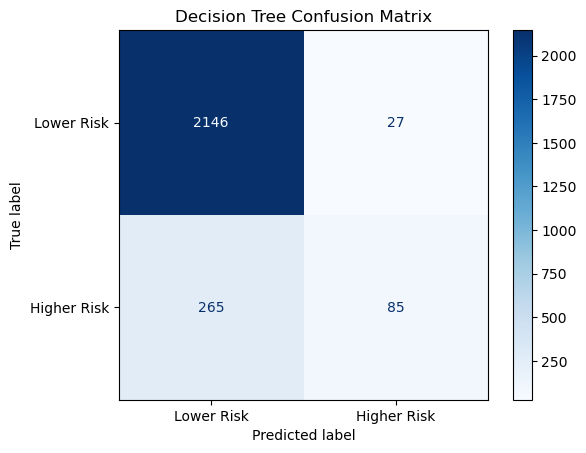

In [7]:
dtclf = DecisionTreeClassifier(max_depth=4, random_state=42)
dtclf.fit(X_train, y_train)

y_pred = dtclf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Lower Risk", "Higher Risk"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()

# RandomForestClassifier

Accuracy: 0.86


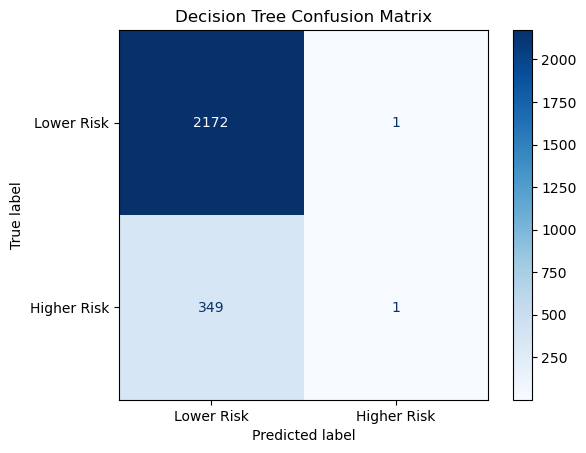

In [8]:
rfclf = RandomForestClassifier(max_depth=4, random_state=42)
rfclf.fit(X_train, y_train)

y_pred = rfclf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Lower Risk", "Higher Risk"])
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.show()

# HistGradientBoostingClassifier

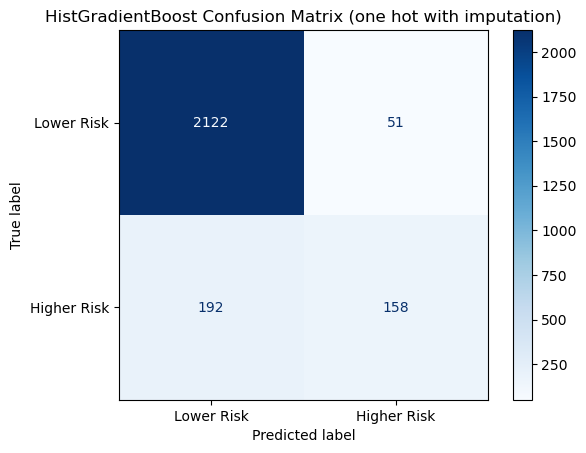

In [9]:
clf = HistGradientBoostingClassifier().fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Lower Risk", "Higher Risk"])
disp.plot(cmap=plt.cm.Blues)
plt.title('HistGradientBoost Confusion Matrix (one hot with imputation)')
plt.show()

# HistGradientBoostingClassifier without one-hot

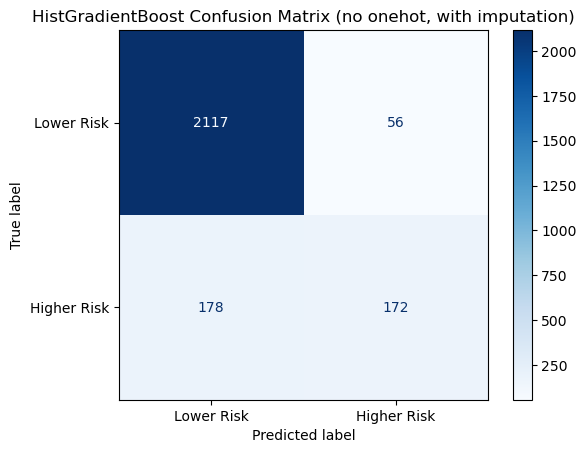

In [10]:
X = data.drop(model.label, axis=1)
X = X.drop("Nest_SBS", axis=1)
X = X.to_numpy()
y = data[model.label].map(mapping).to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

categorical_list = []
example_entry = X[0]

for e in example_entry:
    if isinstance(e, str):
        categorical_list.append(True)
    else:
        categorical_list.append(False)

clf = HistGradientBoostingClassifier(categorical_features=categorical_list).fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Lower Risk", "Higher Risk"])
disp.plot(cmap=plt.cm.Blues)
plt.title('HistGradientBoost Confusion Matrix (no onehot, with imputation)')
plt.show()